# Renoise decorrelation — where does the start state stop knowing the answer?

**Question.** The SDEdit start noises the conditioning field to t_start. How much of the field's
*placement information* (where the high-k energy is; where the PDE residual is) survives that noise,
as a function of t? This pins the t_start trade observationally, before any finetuning experiment.

**Protocol.** For each regime (Re=1000 in-dist, Re=2000 OOD), 16 test frames. Three field families:
- **GT renoised** — the ceiling: even a perfect start decorrelates at this rate; no start can beat it.
- **DDIM-recon renoised** — the base-DDIM-init pipeline's actual start state at each t.
- **LR renoised** — the raw-init pipeline's start state.

At each t ∈ {5..300} (4 noise seeds, averaged): corr of local high-k energy with clean GT's, and corr
of |NS residual| with clean GT's. Clean (t=0) values shown as dashed anchors. Vertical lines: the
candidate policy start levels (50, 100, 150 = S_MULTI).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

for _cand in ('.', '..', '../..', '/home/rhautier/ddpm-jax'):
    if os.path.isdir(os.path.join(_cand, 'flow-data')) and os.path.isdir(os.path.join(_cand, 'monitoring')):
        os.chdir(_cand); break
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src/ddpo_ft'))

from ppo_claude import build_ddim_denoiser
from train_claude import build_base_ddpm
from viz_energy import local_hik_energy
from src.physics_guidance import make_ns_residual
from src.sequence_inference import build_triplets, grid_downsample_degrade, load_sequence

MEAN, STD, N, HIK0 = 0.0, 4.7988, 256, 32
GT_FILE = {1000: 'flow-data/kf_2d_re1000_256_40seed.npy', 2000: 'flow-data/kf_re2000_256_20seed.npy'}
TEST_SEQS = {1000: [36, 37], 2000: [10, 11]}
TS = [5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300]
SEEDS = 4

ddpm, base_params, _ = build_base_ddpm()
ab = ddpm.alpha_bar
ddim = build_ddim_denoiser(ddpm.unet, ab, 100, 20)
_sa, _s1 = float(jnp.sqrt(ab[100])), float(jnp.sqrt(1.0 - ab[100]))
RESID = {re_val: jax.jit(make_ns_residual(n=N, re=float(re_val))) for re_val in (1000, 2000)}
print('jax devices:', jax.devices())

Type of the model constructed with no cond <class 'src.models.model.Unet'>
base DDPM: Unet | epoch 299 | T=1000


jax devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0), TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0), TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0)]


In [2]:
def corr(a, b):
    return float(np.corrcoef(a.ravel(), b.ravel())[0, 1])

def metrics_vs_gt(x, re_val, Ehg, Rg):
    '''(placement corr, residual-placement corr) of triplet batch x vs precomputed GT maps.'''
    Eh = local_hik_energy(np.asarray(x)[..., 1] * STD, HIK0, 6.0)
    R = np.abs(np.asarray(RESID[re_val](jnp.asarray(x) * STD)))
    return corr(Eh, Ehg), corr(R, Rg)

def renoise(x, t, seed):
    k = jax.random.PRNGKey(seed)
    return float(jnp.sqrt(ab[t])) * jnp.asarray(x) + float(jnp.sqrt(1 - ab[t])) * jax.random.normal(k, x.shape)

RES = {}   # (re, family) -> dict(t -> (place, resid_place)); family in gt/ddim/lr; 'clean' anchors
for re_val in (1000, 2000):
    xg, xl = [], []
    for s in TEST_SEQS[re_val]:
        seq = load_sequence(GT_FILE[re_val], s)
        g = build_triplets(seq, MEAN, STD); l = build_triplets(grid_downsample_degrade(seq, 4), MEAN, STD)
        idx = np.linspace(len(g) // 4, len(g) - 1, 8).astype(int)
        xg.append(g[idx]); xl.append(l[idx])
    xg, xl = np.concatenate(xg), np.concatenate(xl)
    kdd = jax.random.PRNGKey(12345)
    xdd = np.asarray(ddim(base_params, _sa * jnp.asarray(xl) + _s1 * jax.random.normal(kdd, xl.shape)))

    Ehg = local_hik_energy(xg[..., 1] * STD, HIK0, 6.0)
    Rg = np.abs(np.asarray(RESID[re_val](jnp.asarray(xg) * STD)))
    RES[(re_val, 'clean')] = {'lr': metrics_vs_gt(xl, re_val, Ehg, Rg),
                              'ddim': metrics_vs_gt(xdd, re_val, Ehg, Rg)}
    for fam, x0 in (('gt', xg), ('ddim', xdd), ('lr', xl)):
        cur = {}
        for t in TS:
            vals = [metrics_vs_gt(renoise(x0, t, 100 * t + s), re_val, Ehg, Rg) for s in range(SEEDS)]
            cur[t] = tuple(np.mean(vals, axis=0))
        RES[(re_val, fam)] = cur
    print(f're{re_val}: clean LR {RES[(re_val, "clean")]["lr"]}, clean DDIM {RES[(re_val, "clean")]["ddim"]}')

re1000: clean LR (0.69863297207935, 0.23392443874151897), clean DDIM (0.7184408999366589, 0.44754304731430405)


re2000: clean LR (0.6854631168239488, 0.21762953155301004), clean DDIM (0.7192826576664395, 0.40572129287750236)


In [3]:
print(f"{'re':>5}{'t':>5} | {'place: GTren':>13}{'DDIMren':>9}{'LRren':>8} | {'resid: GTren':>13}{'DDIMren':>9}{'LRren':>8}")
for re_val in (1000, 2000):
    for t in TS:
        g, d, l = RES[(re_val, 'gt')][t], RES[(re_val, 'ddim')][t], RES[(re_val, 'lr')][t]
        print(f"{re_val:>5}{t:>5} | {g[0]:>13.3f}{d[0]:>9.3f}{l[0]:>8.3f} | {g[1]:>13.3f}{d[1]:>9.3f}{l[1]:>8.3f}")

   re    t |  place: GTren  DDIMren   LRren |  resid: GTren  DDIMren   LRren
 1000    5 |         1.000    0.718   0.699 |         0.235    0.118   0.229
 1000   10 |         0.999    0.718   0.699 |         0.156    0.096   0.222
 1000   20 |         0.998    0.717   0.698 |         0.108    0.082   0.203
 1000   30 |         0.996    0.709   0.696 |         0.092    0.079   0.184
 1000   50 |         0.983    0.686   0.694 |         0.083    0.077   0.150
 1000   75 |         0.943    0.601   0.689 |         0.079    0.076   0.122
 1000  100 |         0.862    0.478   0.674 |         0.077    0.076   0.107
 1000  125 |         0.747    0.365   0.649 |         0.076    0.076   0.097
 1000  150 |         0.607    0.254   0.613 |         0.075    0.075   0.090
 1000  200 |         0.389    0.159   0.514 |         0.074    0.074   0.083
 1000  300 |         0.159    0.069   0.265 |         0.070    0.070   0.073
 2000    5 |         1.000    0.720   0.685 |         0.480    0.126   0.214

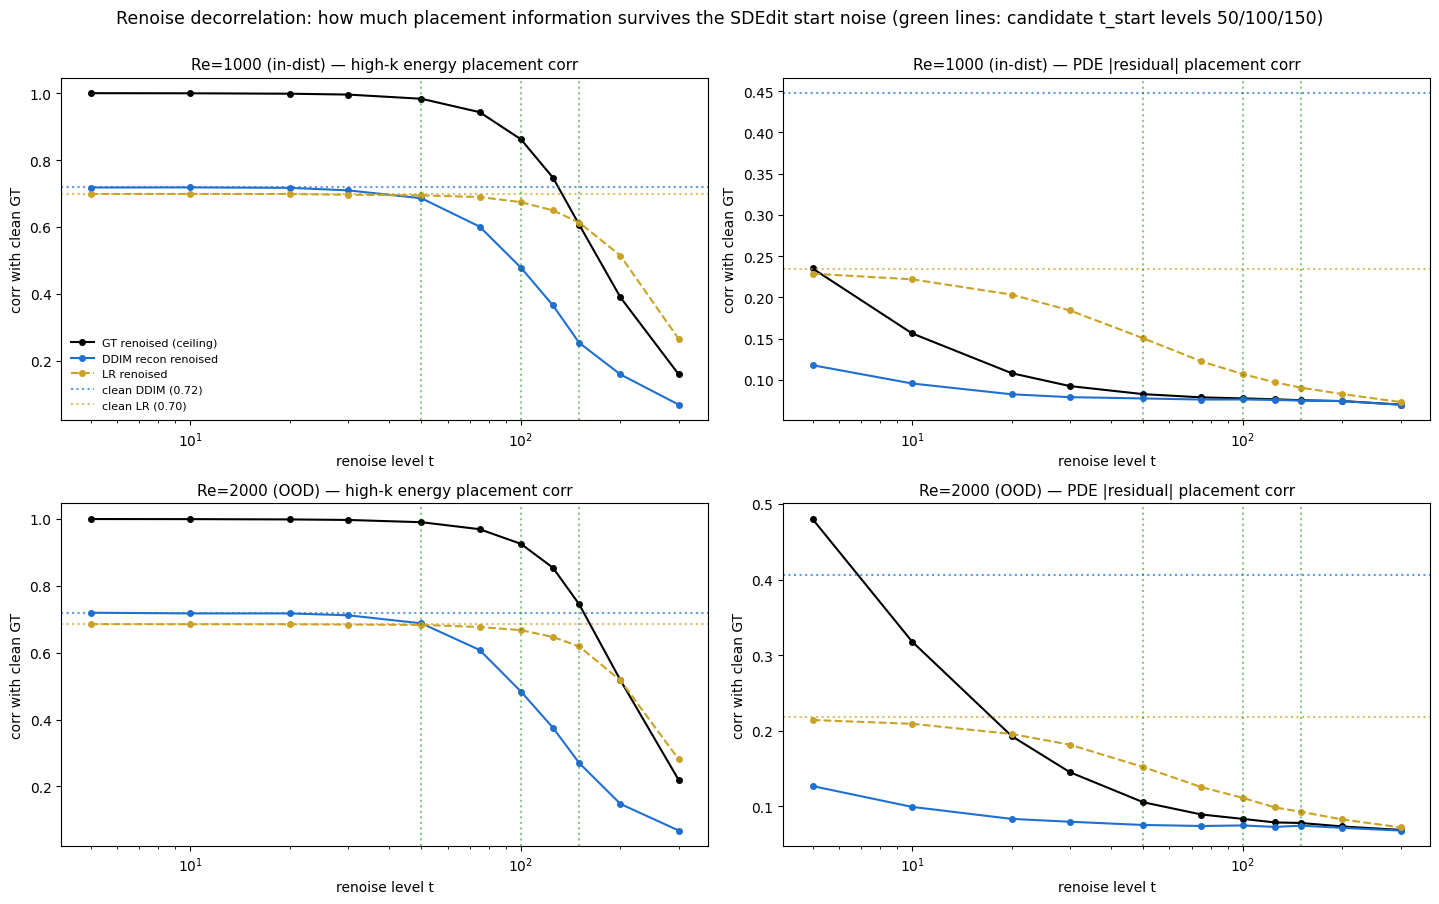

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))
FAM = (('gt', 'GT renoised (ceiling)', 'k', '-'), ('ddim', 'DDIM recon renoised', '#1f6fd0', '-'),
       ('lr', 'LR renoised', '#c9a227', '--'))
for ri, re_val in enumerate((1000, 2000)):
    for ci, (mi, name) in enumerate(((0, 'high-k energy placement corr'), (1, 'PDE |residual| placement corr'))):
        ax = axes[ri, ci]
        for fam, lbl, c, ls in FAM:
            ax.plot(TS, [RES[(re_val, fam)][t][mi] for t in TS], ls, marker='o', ms=4, color=c, label=lbl)
        ax.axhline(RES[(re_val, 'clean')]['ddim'][mi], color='#1f6fd0', ls=':', alpha=.7,
                   label=f"clean DDIM ({RES[(re_val, 'clean')]['ddim'][mi]:.2f})")
        ax.axhline(RES[(re_val, 'clean')]['lr'][mi], color='#c9a227', ls=':', alpha=.7,
                   label=f"clean LR ({RES[(re_val, 'clean')]['lr'][mi]:.2f})")
        for tv in (50, 100, 150):
            ax.axvline(tv, color='green', ls=':', alpha=.45)
        ax.set_xscale('log'); ax.set_xlabel('renoise level t'); ax.set_ylabel('corr with clean GT')
        ax.set_title(f"Re={re_val} ({'in-dist' if re_val == 1000 else 'OOD'}) — {name}", fontsize=11)
        if ri == 0 and ci == 0:
            ax.legend(frameon=False, fontsize=8)
fig.suptitle('Renoise decorrelation: how much placement information survives the SDEdit start noise '
             '(green lines: candidate t_start levels 50/100/150)', y=1.0, fontsize=12.5)
plt.tight_layout()
plt.savefig('monitoring/ab_pdelocal/renoise_decorrelation.png', dpi=115, bbox_inches='tight')
plt.show()

## Reading

- The **GT-renoised** curve is the hard ceiling: no start field can stay better-correlated than a
  perfect field under the same noise.
- Where the **DDIM** and **LR** curves converge, the choice of start field no longer matters at that
  t_start — the noise has erased their difference; the policy can only recover it by denoising skill.
- Where the DDIM curve still clearly exceeds the LR curve, reconstruction information survives in the
  start state itself — a policy started there inherits it for free.
- The drop-off knee tells us the largest t_start that still preserves the DDIM advantage; that's the
  candidate for the shorter-chain finetune.